<a href="https://colab.research.google.com/github/falyseck/Multimodel_Data_Prepocessing/blob/main/audio_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/audio_dataset"

### Loading and displaying sounds as waveforms

/tmp/ipykernel_652/1334011258.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


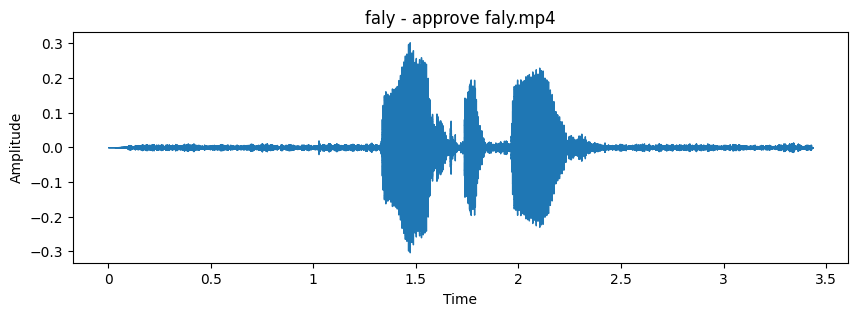

/tmp/ipykernel_652/1334011258.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


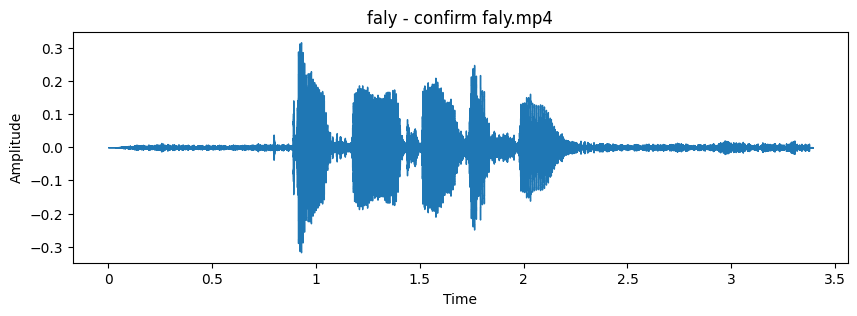

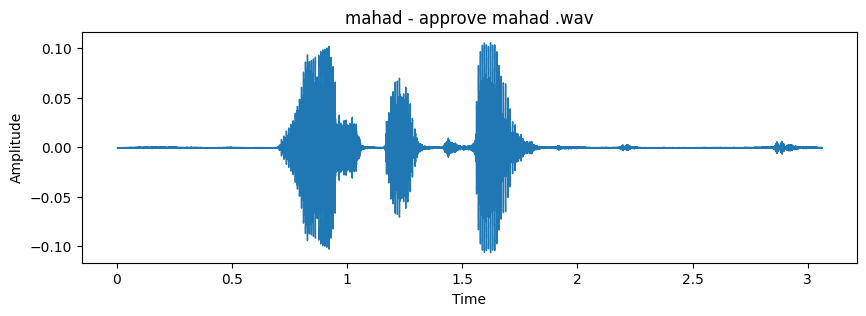

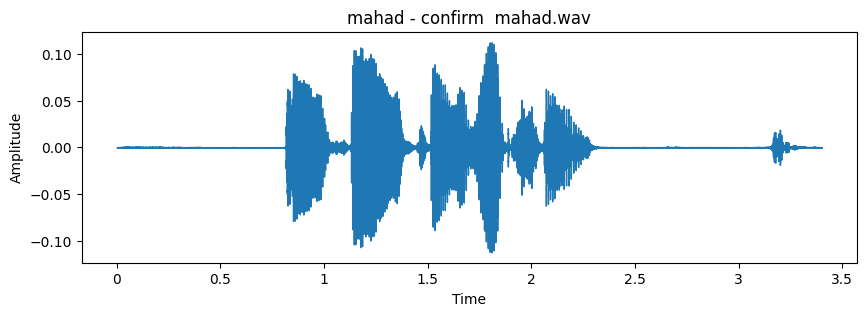

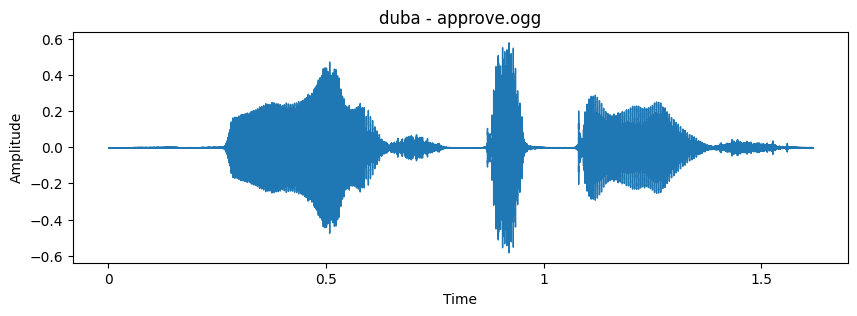

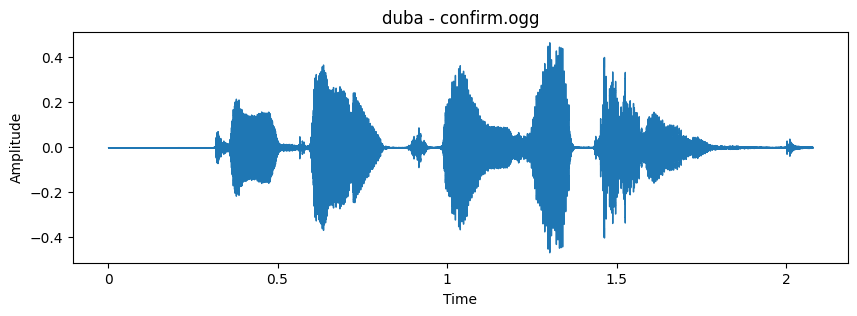

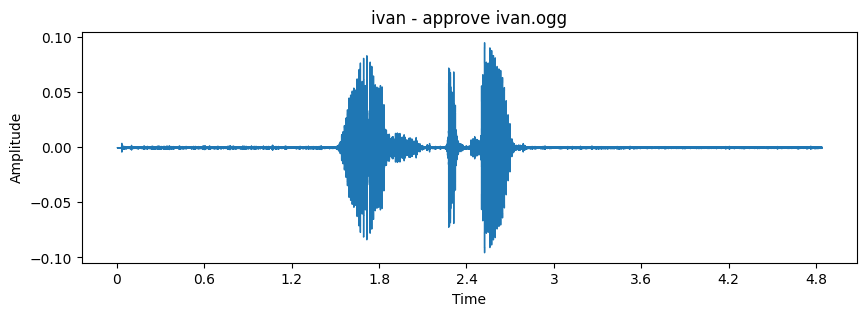

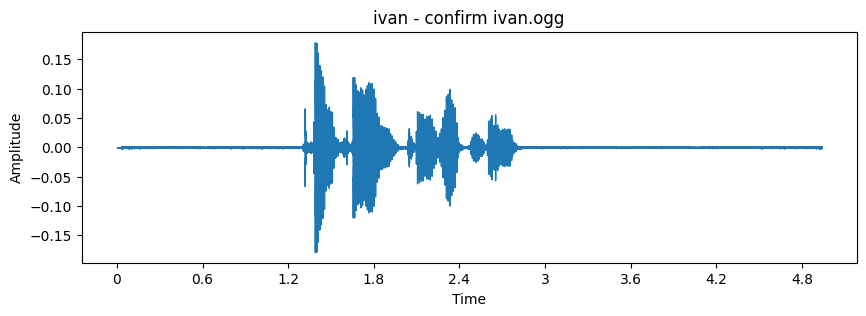

In [4]:
for member in os.listdir(dataset_path):

    member_path = os.path.join(dataset_path, member)

    for audio_file in os.listdir(member_path):

        file_path = os.path.join(member_path, audio_file)

        y, sr = librosa.load(file_path)

        plt.figure(figsize=(10,3))
        librosa.display.waveshow(y, sr=sr)

        plt.title(f"{member} - {audio_file}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")

        plt.show()

### Displaying sounds as spectograms

/tmp/ipykernel_652/3570170586.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


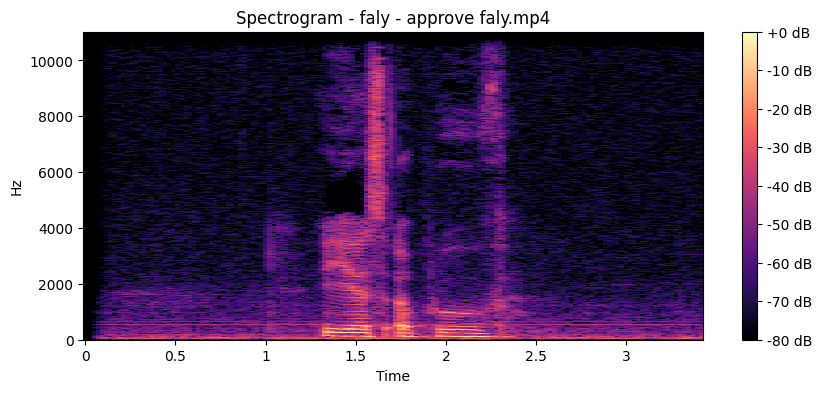

/tmp/ipykernel_652/3570170586.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


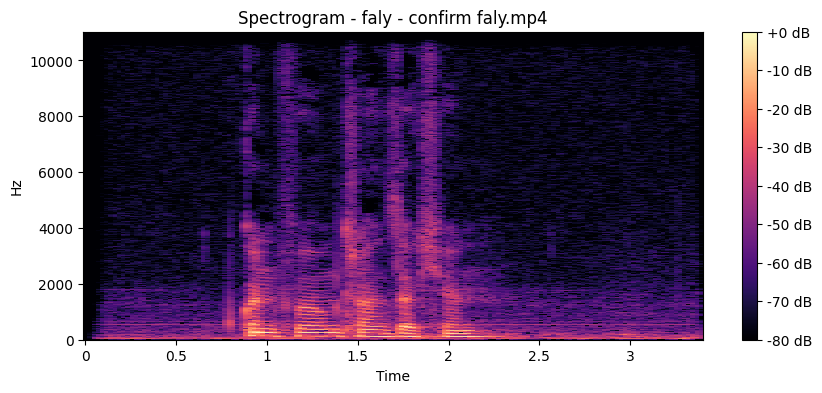

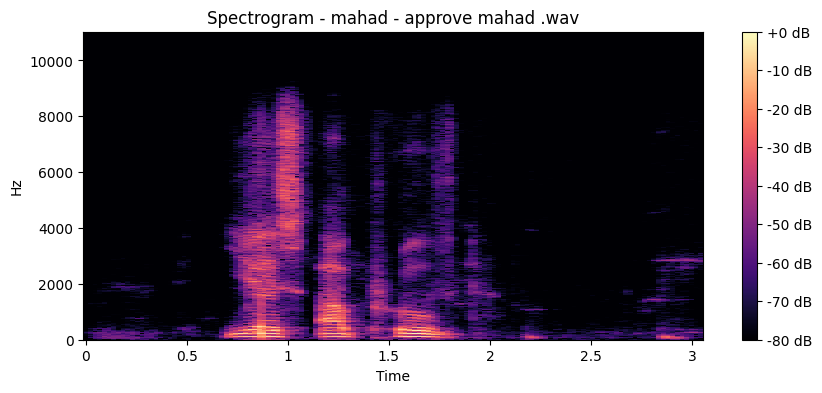

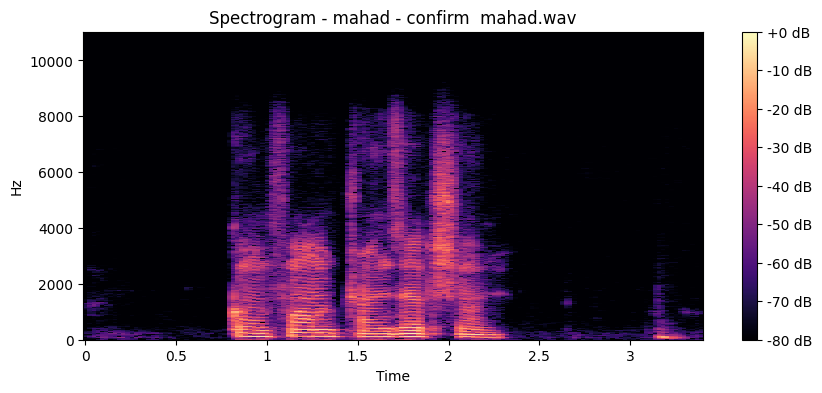

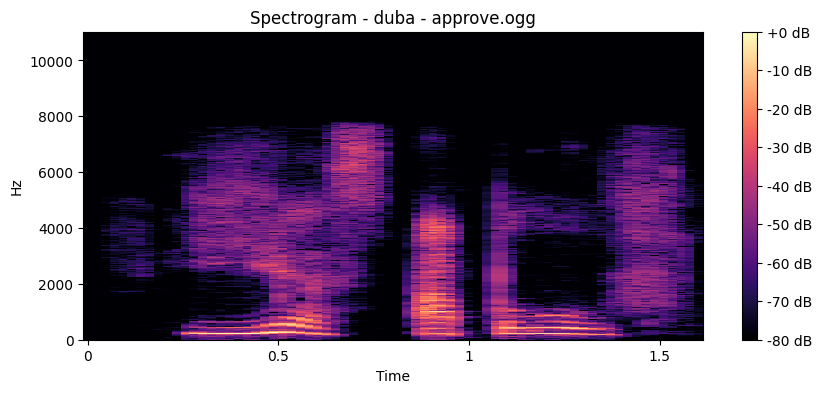

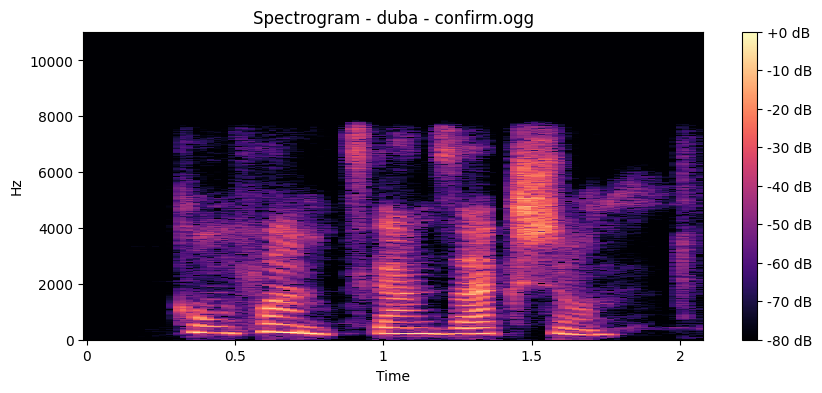

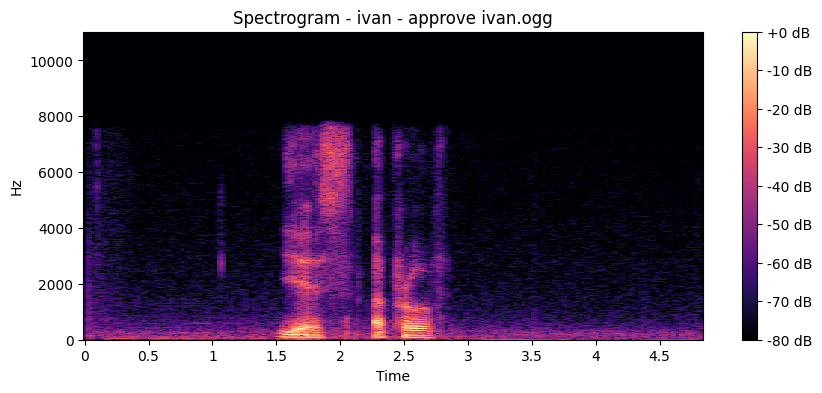

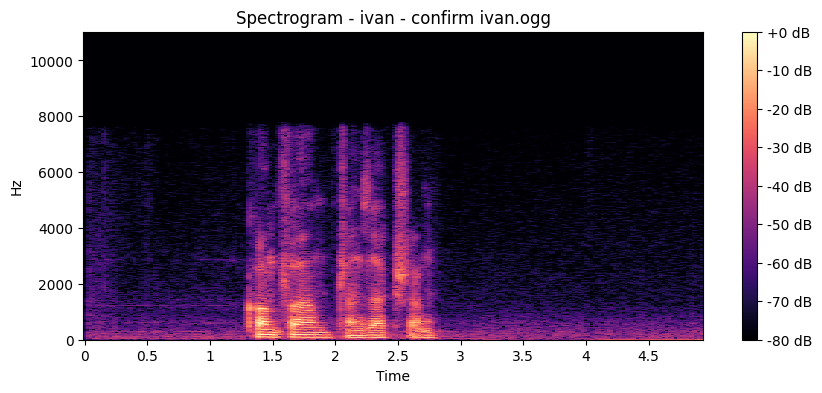

In [5]:
for member in os.listdir(dataset_path):

    member_path = os.path.join(dataset_path, member)

    for audio_file in os.listdir(member_path):

        file_path = os.path.join(member_path, audio_file)

        y, sr = librosa.load(file_path)

        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

        plt.figure(figsize=(10,4))

        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')

        plt.colorbar(format='%+2.0f dB')

        plt.title(f"Spectrogram - {member} - {audio_file}")

        plt.show()

### Audio Augmentation Functions

In [6]:
def pitch_shift(y, sr):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

def time_stretch(y):
    return librosa.effects.time_stretch(y, rate=1.2)

def add_noise(y):
    noise = np.random.randn(len(y))
    return y + 0.005 * noise

### Feature Extraction Functions

In [7]:
def extract_features(y, sr):

    features = []

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)

    features.extend(mfcc_mean)

    # Spectral rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.append(np.mean(rolloff))

    # Energy (RMS)
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))

    return features

### Processing all audios

In [8]:
data = []

for member in os.listdir(dataset_path):

    member_path = os.path.join(dataset_path, member)

    for audio_file in os.listdir(member_path):

        file_path = os.path.join(member_path, audio_file)

        y, sr = librosa.load(file_path)

        # original
        features = extract_features(y, sr)
        data.append([member] + features)

        # pitch shift
        y_pitch = pitch_shift(y, sr)
        features = extract_features(y_pitch, sr)
        data.append([member] + features)

        # time stretch
        y_stretch = time_stretch(y)
        features = extract_features(y_stretch, sr)
        data.append([member] + features)

        # noise
        y_noise = add_noise(y)
        features = extract_features(y_noise, sr)
        data.append([member] + features)

/tmp/ipykernel_652/1236107993.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_652/1236107993.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


### Save to csv

In [9]:
columns = ["person"] + [f"mfcc_{i}" for i in range(13)] + ["spectral_rolloff","energy"]

df = pd.DataFrame(data, columns=columns)

output_path = "/content/drive/MyDrive/audio_features.csv"

df.to_csv(output_path, index=False)

print("Audio features saved successfully!")

Audio features saved successfully!
